<h2>Load Metrics</h2>

In [1]:
import torch
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt

In [37]:
BASE_OUTPUT = "../output"
models = ["unet", "unet++", "deeplabv3"]
metrics = ["train_losses", "val_losses", "train_dices", "val_dices",
           "train_ious", "val_ious", "times"]

In [3]:
History = {}
for model in models: 
    History[model] = {}
    for metric in metrics: 
        v = torch.load(Path(BASE_OUTPUT, model, f'{metric}.pt'))
        History[model][metric] = np.array(v)
        print(f"{metric}'s shape \t: ", History[model][metric].shape)



train_losses's shape 	:  (25,)
val_losses's shape 	:  (25,)
train_dices's shape 	:  (25,)
val_dices's shape 	:  (25,)
train_ious's shape 	:  (25,)
val_ious's shape 	:  (25,)
times's shape 	:  (25, 2)
train_losses's shape 	:  (25,)
val_losses's shape 	:  (25,)
train_dices's shape 	:  (25,)
val_dices's shape 	:  (25,)
train_ious's shape 	:  (25,)
val_ious's shape 	:  (25,)
times's shape 	:  (25, 2)
train_losses's shape 	:  (25,)
val_losses's shape 	:  (25,)
train_dices's shape 	:  (25,)
val_dices's shape 	:  (25,)
train_ious's shape 	:  (25,)
val_ious's shape 	:  (25,)
times's shape 	:  (25, 2)


# Curves Visualization

<h2>Validation Metrics Curves Visualization</h2>

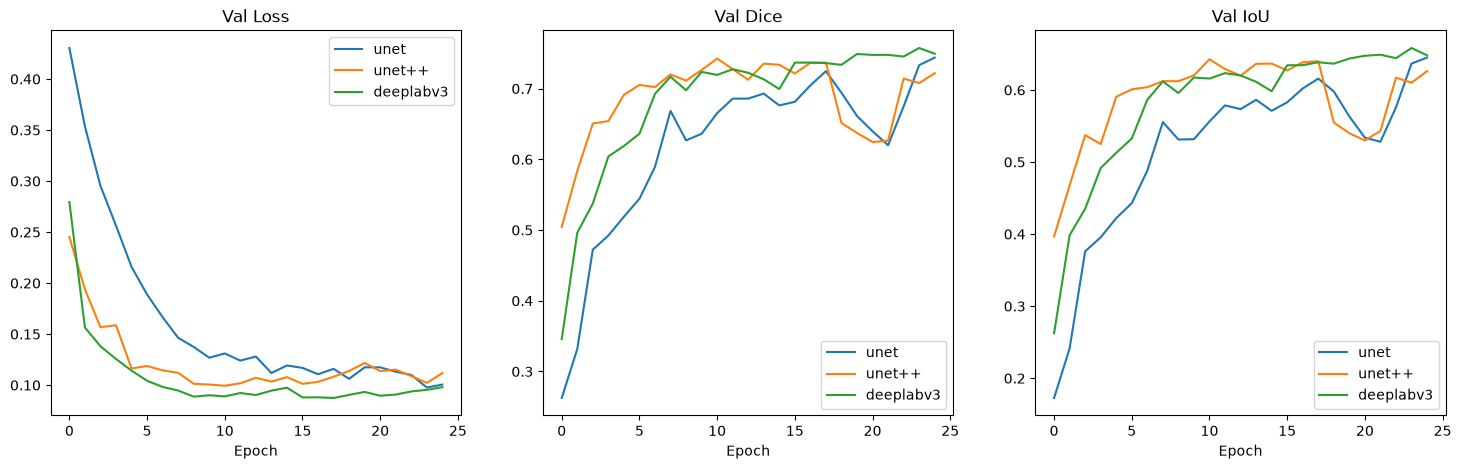

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))
for m in models:
    ax[0].plot(History[m]["val_losses"], label=m)
    ax[1].plot(History[m]["val_dices"], label=m)
    ax[2].plot(History[m]["val_ious"], label=m)

for a, t in zip(ax, ["Val Loss", "Val Dice", "Val IoU"]):
    a.set_title(t); a.set_xlabel("Epoch")
    a.legend()
    
plt.show()

**Observations (validation curves):**

- **Convergence speed:** DeepLabV3 and U-Net++ start from a lower validation loss than U-Net (≈0.28 and ≈0.25 vs ≈0.43). U-Net++ is the fastest in Dice/IoU during the first epochs (Dice ≈ 0.70 by epoch 5), while U-Net is the slowest to converge.
- **Final performance:** All three models end with a similar validation loss (≈0.10). DeepLabV3 reaches the highest Dice (≈0.75) and IoU (≈0.66), followed closely by U-Net (≈0.74 / 0.645) and U-Net++ (≈0.72 / 0.625).
- **Stability:** DeepLabV3 is the most stable, with a smooth and nearly monotonic improvement. U-Net and U-Net++ show a noticeable drop in Dice/IoU around epochs 18-21 (drop to ≈0.62 for Dice and ≈0.53 for IoU), followed by a recovery. This drop is barely visible in the validation loss, suggesting the loss and the overlap metrics do not always move together.
- **Remaining margin:** U-Net is still improving at the last epoch, so it may benefit from longer training. The final gaps between models are small (≈0.01-0.03 Dice), so they should be confirmed on the test set before drawing conclusions.

<h2> Training Curves Visualization</h2>

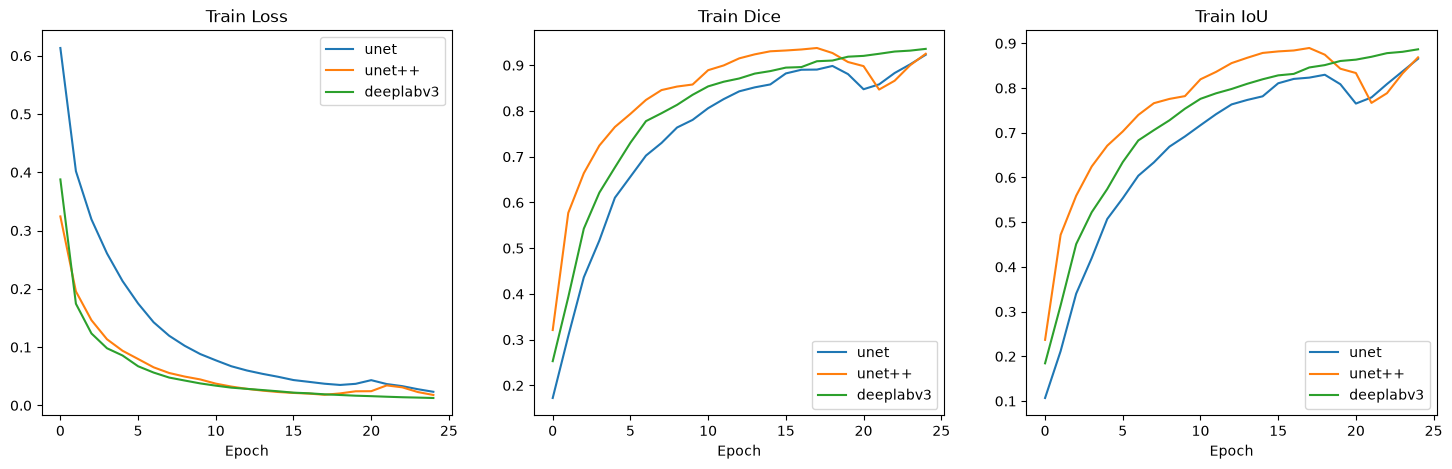

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for m in models: 
    ax[0].plot(History[m]["train_losses"], label=m)
    ax[1].plot(History[m]["train_dices"], label=m)
    ax[2].plot(History[m]["train_ious"], label=m)

for a, t in zip (ax, ["Train Loss", "Train Dice", "Train IoU"]):
    a.set_title(t)
    a.set_xlabel("Epoch")
    a.legend()

plt.show()

**Observations (training curves):**

- **Convergence speed:** DeepLabV3 and U-Net++ start from a lower training loss than U-Net (≈0.39 and ≈0.33 vs ≈0.62). U-Net++ is the fastest in Dice/IoU during the 18 epochs (Dice ≈ 0.95 by epoch 18), while U-Net is the slowest to converge.
- **Final performance:** All three models end with a similar training loss (≈0.02). DeepLabV3 reaches the highest Dice (≈0.94) and IoU (≈0.89), followed closely by U-Net and U-Net++ (≈0.93 / 0.87).
- **Stability:** DeepLabV3 is the most stable, with a smooth and nearly monotonic improvement. U-Net and U-Net++ show a noticeable drop in Dice/IoU around epochs 18-21 (drop to ≈0.83 for Dice and ≈0.76 for IoU), followed by a recovery. This drop is barely visible in the training loss, suggesting the loss and the overlap metrics do not always move together.
- **Remaining margin:** U-Net and U-Net++ are still improving at the last epoch, so it may benefit from longer training. The final gaps between models are small (≈0.01-0.03 Dice), so they should be confirmed on the test set before drawing conclusions.

<h2>Training and Validation Curves</h2>

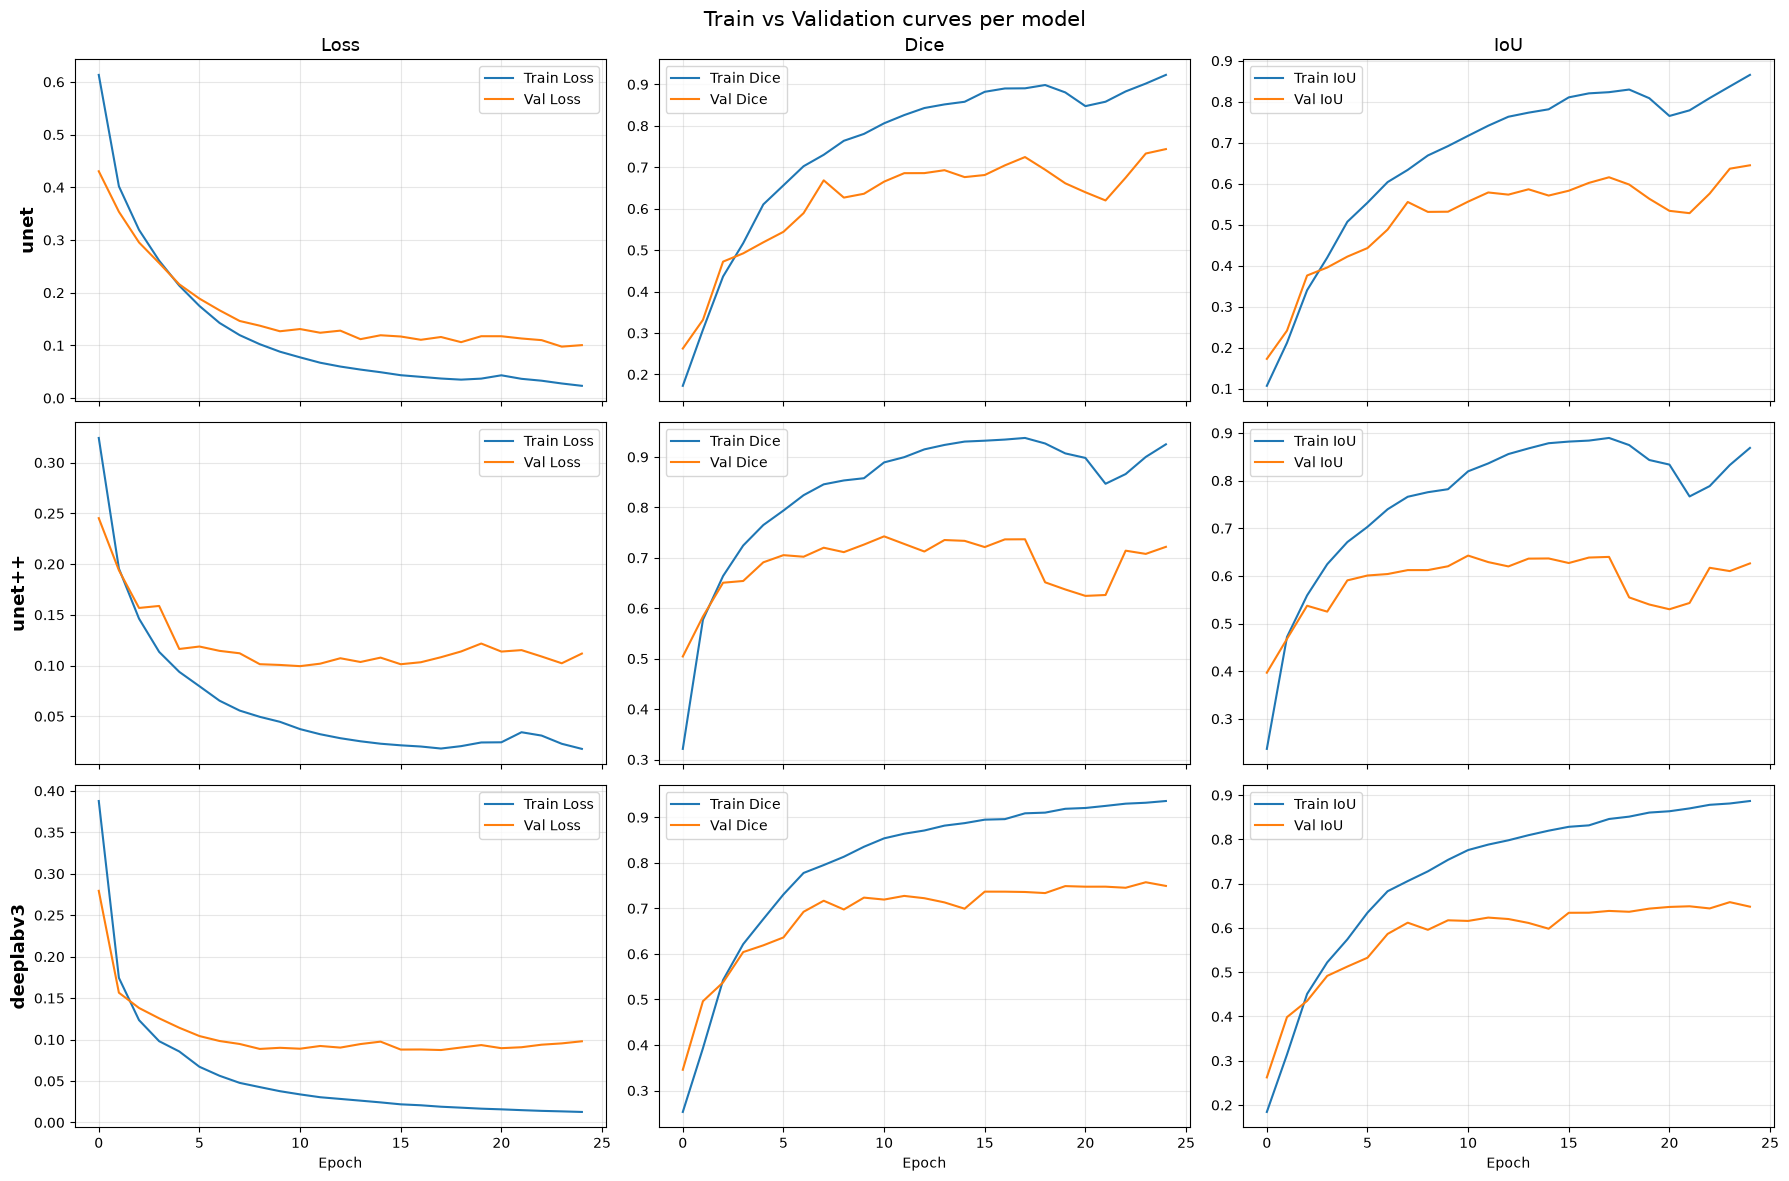

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for idx, m in enumerate(models):
    ax[idx][0].plot(History[m]["train_losses"], label="Train Loss")
    ax[idx][0].plot(History[m]["val_losses"], label="Val Loss")
    ax[idx][1].plot(History[m]["train_dices"], label="Train Dice")
    ax[idx][1].plot(History[m]["val_dices"], label="Val Dice")
    ax[idx][2].plot(History[m]["train_ious"], label="Train IoU")
    ax[idx][2].plot(History[m]["val_ious"], label="Val IoU")

    ax[idx][0].set_ylabel(m, fontsize=13, fontweight="bold")

for j, name in enumerate(["Loss", "Dice", "IoU"]):
    ax[0][j].set_title(name, fontsize=13)

for axs in ax:
    for a in axs:
        a.legend()
        a.grid(alpha=0.3)

for a in ax[-1]:
    a.set_xlabel("Epoch")

fig.suptitle("Train vs Validation curves per model", fontsize=15)
plt.tight_layout()
# plt.savefig("figures/all_models_train_vs_val.png", dpi=300)
plt.show()

In [27]:
ax[0][0].imshow(np.random.randint(0, 255, (100, 100)))
plt.show()